In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from gridworld_env import get_task1_gridworld, get_task2_gridworld, get_task3_gridworld

In [8]:
# Function for visualising the environment and plotting the preferred actions taken at each grid location for task 1.
def plot_actions(env, Q, algorithm):
    actions = ['N', 'E', 'S', 'W'] # The 4 possible actions (North, East, South, West).
    optimal_actions = np.argmax(Q, axis=1) # Obtaining the actions that result in the largest rewards (Preferred actions).
    
    grid_shape = env.get_gridshape() # Dimensions of the environment.
    lava_locs = env.get_lava_loc() # Locations of the lava.
    walls_locs = env.get_walls_loc() # Locations of the walls.
    reward_loc = env.get_goal_loc()[0] # Location of the target
    start_loc = env.get_starting_loc() # Starting location.

    fig, ax = plt.subplots()
    ax.set_xticks(np.arange(0, grid_shape[1]+1, 1))
    ax.set_yticks(np.arange(0, grid_shape[0]+1, 1))
    ax.set_xticklabels(list(range(0,11)))
    ax.set_yticklabels(list(range(0,14)))
    ax.grid(which='both')

    for wall_loc in walls_locs:
        # Painting the locations of the walls in black.
        rect = patches.Rectangle((wall_loc[1], wall_loc[0]), 1, 1, linewidth=1, edgecolor='black', facecolor='black')
        ax.add_patch(rect)
    for lava_loc in lava_locs:
        # Painting the locations of the lava in red.
        rect = patches.Rectangle((lava_loc[1], lava_loc[0]), 1, 1, linewidth=1, edgecolor='red', facecolor='red')
        ax.add_patch(rect)
    
    # Painting the location of the target in blue.
    rect = patches.Rectangle((reward_loc[1], reward_loc[0]), 1, 1, linewidth=1, edgecolor='blue', facecolor='blue')
    ax.add_patch(rect)

    # Painting the location of the start location in yellow.
    rect = patches.Rectangle((start_loc[1], start_loc[0]), 1, 1, linewidth=1, edgecolor='yellow', facecolor='yellow')
    ax.add_patch(rect)

    # Adding arrows to each grid location to indicate the preferred action taken in a specific state/grid location.
    for i in range(grid_shape[0]):
        for j in range(grid_shape[1]):
            loc = (i,j)
            if loc != reward_loc and loc != start_loc and loc not in lava_locs and loc not in walls_locs:
                action = actions[optimal_actions[env._get_state_from_loc(loc)]]
                if action == 'N':
                    plt.arrow(j+0.5, i+0.8, 0, -0.6, head_width=0.2, head_length=0.2, fc='k', ec='k')
                elif action == 'E':
                    plt.arrow(j+0.2, i+0.5, 0.6, 0, head_width=0.2, head_length=0.2, fc='k', ec='k')
                elif action == 'S':
                    plt.arrow(j+0.5, i+0.2, 0, 0.6, head_width=0.2, head_length=0.2, fc='k', ec='k')
                elif action == 'W':
                    plt.arrow(j+0.8, i+0.5, -0.6, 0, head_width=0.2, head_length=0.2, fc='k', ec='k')
    
    # Giving the figure a title based on the algorithm used.
    if algorithm == 'sarsa':
        plt.title('Preferred Actions (SARSA)')
    elif algorithm == 'qlearning':
        plt.title('Preferred Actions (Q-learning)')
    
    plt.gca().invert_yaxis()
    plt.show()   

In [9]:
# The definition of the 'Q-learning' algorithm.
class Q_agent():
    
    # The definition of the 'epsilon-greedy' policy. 
    def epsilon_greedy_policy(self, Q, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(4) # Selecting a random action if the random number is less than the epsilon value.
        else:
            max_value = np.max(Q[state])
            best_actions = np.flatnonzero(Q[state] == max_value)
            if not best_actions.size:
                return np.random.randint(4)
            else:
                return np.random.choice(best_actions) # Selecting the action that will give the best reward.
    
    # The definition of the 'Softmax' policy.
    def soft_max_policy(self, Q, state, tau):
        max_Q = np.max(Q[state])
        exp_Q = np.exp((Q[state] - max_Q) / tau)
        prob = exp_Q / np.sum(exp_Q)
        prob = np.nan_to_num(prob, nan = 0.0)
        return np.random.choice(range(4), p=prob) # Selecting a random action based on given probabilities.
    
    # The definition of the algorithm's solving method.
    def solve(self, env, gamma, alpha, epsilon, pol, task, n_episodes=5000, runs=50, lambda_ = 0.85):
        tr = []
        ts = []
        final_Q = []

        for i in range(runs):
            Q = np.zeros((124, 4)) # Initializing the Q-table.
            if task == 'task3':
                E = np.zeros((124, 4))  # Initializing the eligibility trace for task 3.
            total_rewards = [] # Initializing an array to store the rewards across all episodes.
            total_steps = [] # Initializing an array to store the steps across all episodes.

            for j in range(n_episodes): # Looping through all episodes
                _, state, reward, done = env.reset() # Obtaining the state, reward, and whether the episode has been terminated at the starting location.
                episode_reward = 0
                episode_steps = 0

                if task == 'task3' and j == 0:  # Initialize the eligibility trace only for the first episode
                    E = np.zeros((124, 4))

                while not done: # While the episode hasn't terminated.
                    if pol == 'soft-max':
                        action = self.soft_max_policy(Q, state, 0.3) # Selecting an action if the 'Softmax' policy was chosen.
                    elif pol == 'epsilon-greedy':
                        action = self.epsilon_greedy_policy(Q, state, epsilon) # Selecting an action if the 'epsilon-greedy' policy was chosen.
                    _, next_state, reward, done = env.step(action) # Obtaining the next state, the corresponding reward, and if the episode terminated.
                    target = np.max(Q[next_state]) # Selecting the target value as the largest Q value in the next state.
                    if task == 'task3':
                        E[state][action] += 1
                        Q[state][action] += alpha * (reward + gamma * target - Q[state][action]) * E[state][action] # Updating the Q-table.
                        E *= gamma * lambda_
                    else:
                        Q[state][action] += alpha * (reward + gamma * target - Q[state][action]) # Updating the Q-table.
                    state = next_state # Setting the next state as the current state.
                    episode_reward += reward
                    episode_steps += 1
            
                total_rewards.append(episode_reward)
                total_steps.append(episode_steps)
            
            final_Q.append(Q)
            tr.append(total_rewards)
            ts.append(total_steps)
        
        # Averaging the rewards, steps, and Q-table across the 50 runs.
        avg_rewards = np.mean(tr, axis=0)
        avg_steps = np.mean(ts, axis=0)
        avg_q = np.mean(final_Q, axis=0)
    
        return avg_q, avg_rewards, avg_steps

In [10]:
# The definition of the 'SARSA' algorithm.
class SARSA_agent():

    # The definition of the 'epsilon-greedy' policy. 
    def epsilon_greedy_policy(self, Q, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(4) # Selecting a random action if the random number is less than the epsilon value.
        else:
            max_value = np.max(Q[state])
            best_actions = np.flatnonzero(Q[state] == max_value)
            return np.random.choice(best_actions) # Selecting the action that will give the best reward.
    
    # The definition of the 'Softmax' policy.
    def soft_max_policy(self, Q, state, tau):
        max_Q = np.max(Q[state])
        exp_Q = np.exp((Q[state] - max_Q) / tau)
        prob = exp_Q / np.sum(exp_Q)
        prob = np.nan_to_num(prob, nan = 0.0)
        return np.random.choice(range(4), p=prob) # Selecting a random action based on given probabilities.
    
    # The definition of the algorithm's solving method.
    def solve(self, env, gamma, alpha,epsilon,pol, task, n_episodes=5000, runs=50, lambda_ = 0.85):
        tr = []
        ts = []
        final_Q = []

        for i in range(runs):
            Q = np.zeros((124, 4)) # Initializing the Q-table.
            if task == 'task3':
                E = np.zeros((124, 4))  # Initializing the eligibility trace for task 3.
            total_rewards = [] # Initializing an array to store the rewards across all episodes.
            total_steps = [] # Initializing an array to store the steps across all episodes.

            for j in range(n_episodes): # Looping through all episodes
                _, state, reward, done = env.reset() # Obtaining the state, reward, and whether the episode has been terminated at the starting location.
                episode_reward = 0
                episode_steps = 0

                if pol == 'soft-max':
                    action = self.soft_max_policy(Q, state, 0.3) # Selecting an action if the 'Softmax' policy was chosen.
                elif pol == 'epsilon-greedy':
                    action = self.epsilon_greedy_policy(Q, state, epsilon) # Selecting an action if the 'epsilon-greedy' policy was chosen.

                while not done: # While the episode hasn't terminated.
                    if pol == 'soft-max':
                        _, next_state, reward, done = env.step(action) # Obtaining the next state, the corresponding reward, and if the episode terminated.
                        next_action = self.soft_max_policy(Q, next_state, 0.3) # Selecting the next action if the 'Softmax' policy was chosen.
                    elif pol == 'epsilon-greedy':
                        _, next_state, reward, done = env.step(action) # Obtaining the next state, the corresponding reward, and if the episode terminated.
                        next_action = self.epsilon_greedy_policy(Q, next_state, epsilon) # Selecting the next action if the 'epsilon-greedy' policy was chosen.
                    target = Q[next_state][next_action] # Setting the target as the value of the next state and next action pair in the Q-table.
                    if task == 'task3':
                        delta = reward + gamma * target - Q[state][action]
                        E[state][action] += 1
                        Q += alpha * delta * E
                        E *= gamma * lambda_
                    else:
                        Q[state][action] += alpha * (reward + gamma * target - Q[state][action]) # Updating the Q-table.
                    state = next_state # Setting the next state as the current state.
                    action = next_action # Setting the next action as the current action.
                    episode_reward += reward
                    episode_steps += 1
            
                total_rewards.append(episode_reward)
                total_steps.append(episode_steps)
        
            final_Q.append(Q)
            tr.append(total_rewards)
            ts.append(total_steps)
        
        # Averaging the rewards, steps, and Q-table across the 50 runs.
        avg_rewards = np.mean(tr, axis=0)
        avg_steps = np.mean(ts, axis=0)
        avg_q = np.mean(final_Q, axis=0)
        
        
        return avg_q, avg_rewards, avg_steps

# Task 1 - Single Target, Deterministic Rewards:

In [11]:
# Setting the parameters.
env1 = get_task1_gridworld() # Definition of the gridworld in task 1.
gamma = 0.99
alpha = 0.1
epsilon = 0.5
epsilon2 = 0.1

In [12]:
# Note: This took 108 minutes to run on my PC.

agent1 = SARSA_agent() # Initializing the SARSA algorithm.

# Training the SARSA algorithm using the 'epsilon-greedy' policy and experimenting with different exploration rates.
Q_sarsa, rewards_sarsa, steps_sarsa = agent1.solve(env1, gamma, alpha, epsilon, 'epsilon-greedy', 'task1')
Q_sarsa2, rewards_sarsa2, steps_sarsa2 = agent1.solve(env1, gamma, alpha, epsilon2, 'epsilon-greedy', 'task1')

# Training the SARSA algorithm using the 'Softmax' policy.
Q_sarsa3, rewards_sarsa3, steps_sarsa3 = agent1.solve(env1, gamma, alpha, epsilon, 'soft-max', 'task1')

In [13]:
# Note: This took 11 minutes to run on my PC.

agent2 = Q_agent() # Initializing the Q-learning algorithm.

# Training the Q-learning algorithm using the 'epsilon-greedy' policy and experimenting with different exploration rates.
Q_qlearning, rewards_qlearning, steps_qlearning = agent2.solve(env1, gamma, alpha, epsilon, 'epsilon-greedy', 'task1')
Q_qlearning2, rewards_qlearning2, steps_qlearning2 = agent2.solve(env1, gamma, alpha, epsilon2, 'epsilon-greedy', 'task1')

# Training the Q-learning algorithm using the 'Softmax' policy.
Q_qlearning3, rewards_qlearning3, steps_qlearning3 = agent2.solve(env1, gamma, alpha, epsilon, 'soft-max', 'task1')

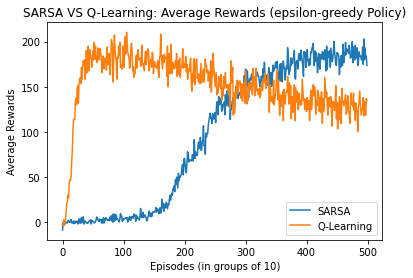

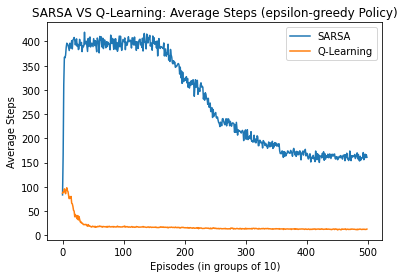

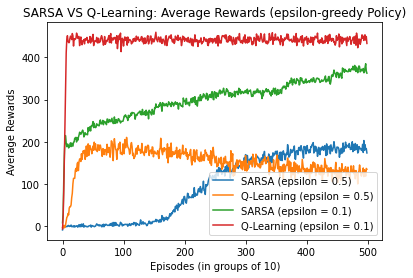

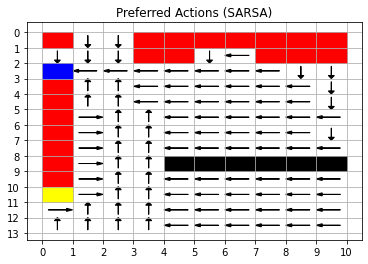

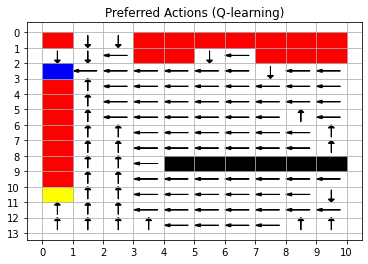

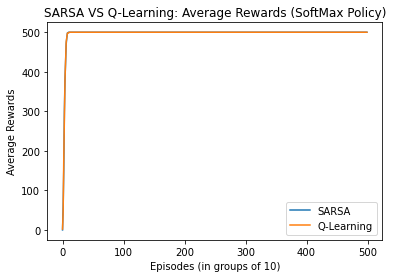

In [14]:
# Plotting

# Average rewards plots (epsilon-greedy).
plt.plot(np.mean(np.array(rewards_sarsa).reshape(-1, 10), axis=1), label = 'SARSA')
plt.plot(np.mean(np.array(rewards_qlearning).reshape(-1, 10), axis=1), label = 'Q-Learning')
plt.xlabel('Episodes (in groups of 10)')
plt.ylabel('Average Rewards')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average steps (epsilon-greedy).
plt.plot(np.mean(np.array(steps_sarsa).reshape(-1, 10), axis=1), label = 'SARSA')
plt.plot(np.mean(np.array(steps_qlearning).reshape(-1, 10), axis=1), label = 'Q-Learning')
plt.xlabel('Episodes (in groups of 10)')
plt.ylabel('Average Steps')
plt.title('SARSA VS Q-Learning: Average Steps (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots for different exploration rates.
plt.plot(np.mean(np.array(rewards_sarsa).reshape(-1, 10), axis=1), label = 'SARSA (epsilon = 0.5)')
plt.plot(np.mean(np.array(rewards_qlearning).reshape(-1, 10), axis=1), label = 'Q-Learning (epsilon = 0.5)')
plt.plot(np.mean(np.array(rewards_sarsa2).reshape(-1, 10), axis=1), label = 'SARSA (epsilon = 0.1)')
plt.plot(np.mean(np.array(rewards_qlearning2).reshape(-1, 10), axis=1), label = 'Q-Learning (epsilon = 0.1)')
plt.xlabel('Episodes (in groups of 10)')
plt.ylabel('Average Rewards')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Plotting the preferred actions.
plot_actions(env1, Q_sarsa, 'sarsa')
plot_actions(env1, Q_qlearning, 'qlearning')

# Average rewards plots (Softmax).
plt.plot(np.mean(np.array(rewards_sarsa3).reshape(-1, 10), axis=1), label = 'SARSA')
plt.plot(np.mean(np.array(rewards_qlearning3).reshape(-1, 10), axis=1), label = 'Q-Learning')
plt.xlabel('Episodes (in groups of 10)')
plt.ylabel('Average Rewards')
plt.title('SARSA VS Q-Learning: Average Rewards (SoftMax Policy)')
plt.legend()
plt.show()


# Task 2 - Dual Targets with Stochastic Rewards

In [15]:
# Setting the parameters.
env2 = get_task2_gridworld() # Definition of the gridworld in task 2.
gamma1 = 0.99
gamma2 = 0.1
epsilon3 = 0.9
epsilon1 = 0.5
epsilon2 = 0.1
alpha1 = 0.1
alpha2 = 0.9

In [16]:
# Note: This took 280 minutes to run on my PC.

agent1 = SARSA_agent() # Initializing the SARSA algorithm.

# Creating several instances of the SARSA algorithm in-order to experiment with different hyperparameters.
Q_sarsa, rewards_sarsa, steps_sarsa = agent1.solve(env2, gamma1, alpha1, epsilon1, 'epsilon-greedy', 'task1')
Q_sarsa2, rewards_sarsa2, steps_sarsa2 = agent1.solve(env2, gamma1, alpha1, epsilon2, 'epsilon-greedy', 'task1')
Q_sarsa3, rewards_sarsa3, steps_sarsa3 = agent1.solve(env2, gamma1, alpha1, epsilon3, 'epsilon-greedy', 'task1')
Q_sarsa4, rewards_sarsa4, steps_sarsa4 = agent1.solve(env2, gamma2, alpha1, epsilon1, 'epsilon-greedy', 'task1')
Q_sarsa5, rewards_sarsa5, steps_sarsa5 = agent1.solve(env2, gamma1, alpha2, epsilon1, 'epsilon-greedy', 'task1')

# Improving the performance of the SARSA algorithm by switching to the 'Softmax' policy.
Q_sarsa7, rewards_sarsa7, steps_sarsa7 = agent1.solve(env2, gamma1, alpha1, epsilon2, 'soft-max', 'task1')

In [17]:
# Note: This took 28 minutes to run on my PC.

agent2 = Q_agent() # Initializing the Q-learning algorithm

# Creating several instances of the SARSA algorithm in-order to experiment with different hyperparameters.
Q_qlearning, rewards_qlearning, steps_qlearning = agent2.solve(env2, gamma1, alpha1, epsilon1, 'epsilon-greedy', 'task1')
Q_qlearning2, rewards_qlearning2, steps_qlearning2 = agent2.solve(env2, gamma1, alpha1, epsilon2, 'epsilon-greedy', 'task1')
Q_qlearning3, rewards_qlearning3, steps_qlearning3 = agent2.solve(env2, gamma1, alpha1, epsilon3, 'epsilon-greedy', 'task1')
Q_qlearning4, rewards_qlearning4, steps_qlearning4 = agent2.solve(env2, gamma2, alpha1, epsilon1, 'epsilon-greedy', 'task1')
Q_qlearning5, rewards_qlearning5, steps_qlearning5 = agent2.solve(env2, gamma1, alpha2, epsilon1, 'epsilon-greedy', 'task1')

# Improving the performance of the Q-learning algorithm by switching to the 'Softmax' policy.
Q_qlearning7, rewards_qlearning7, steps_qlearning7 = agent2.solve(env2, gamma1, alpha1, epsilon2, 'soft-max', 'task1')

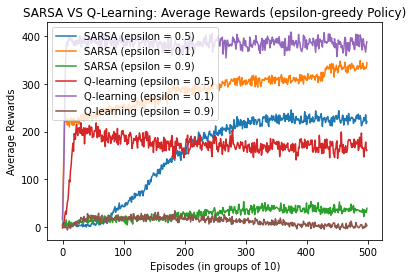

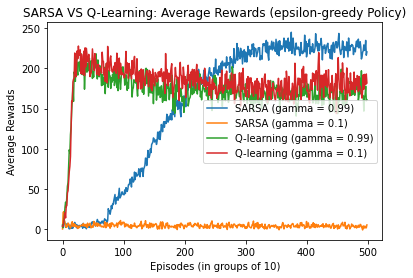

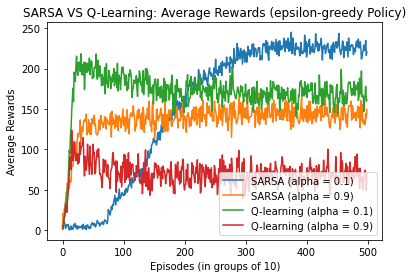

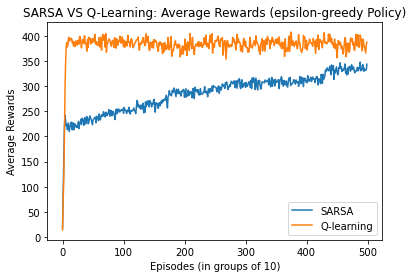

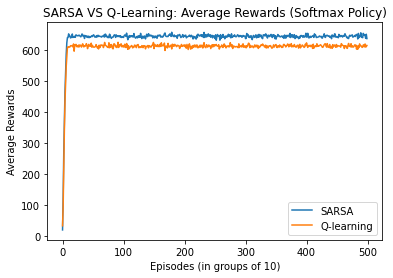

In [18]:
# Plotting

# Average rewards plots for different exploration rates.
plt.plot(np.mean(np.array(rewards_sarsa).reshape(-1, 10), axis=1), label = 'SARSA (epsilon = 0.5)')
plt.plot(np.mean(np.array(rewards_sarsa2).reshape(-1, 10), axis=1), label = 'SARSA (epsilon = 0.1)')
plt.plot(np.mean(np.array(rewards_sarsa3).reshape(-1, 10), axis=1), label = 'SARSA (epsilon = 0.9)')
plt.plot(np.mean(np.array(rewards_qlearning).reshape(-1, 10), axis=1), label = 'Q-learning (epsilon = 0.5)')
plt.plot(np.mean(np.array(rewards_qlearning2).reshape(-1, 10), axis=1), label = 'Q-learning (epsilon = 0.1)')
plt.plot(np.mean(np.array(rewards_qlearning3).reshape(-1, 10), axis=1), label = 'Q-learning (epsilon = 0.9)')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots for different discount factors.
plt.plot(np.mean(np.array(rewards_sarsa).reshape(-1, 10), axis=1), label = 'SARSA (gamma = 0.99)')
plt.plot(np.mean(np.array(rewards_sarsa4).reshape(-1, 10), axis=1), label = 'SARSA (gamma = 0.1)')
plt.plot(np.mean(np.array(rewards_qlearning).reshape(-1, 10), axis=1), label = 'Q-learning (gamma = 0.99)')
plt.plot(np.mean(np.array(rewards_qlearning4).reshape(-1, 10), axis=1), label = 'Q-learning (gamma = 0.1)')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots for different learning rates.
plt.plot(np.mean(np.array(rewards_sarsa).reshape(-1, 10), axis=1), label = 'SARSA (alpha = 0.1)')
plt.plot(np.mean(np.array(rewards_sarsa5).reshape(-1, 10), axis=1), label = 'SARSA (alpha = 0.9)')
plt.plot(np.mean(np.array(rewards_qlearning).reshape(-1, 10), axis=1), label = 'Q-learning (alpha = 0.1)')
plt.plot(np.mean(np.array(rewards_qlearning5).reshape(-1, 10), axis=1), label = 'Q-learning (alpha = 0.9)')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots (epsilon-greedy).
plt.plot(np.mean(np.array(rewards_sarsa2).reshape(-1, 10), axis=1), label = 'SARSA')
plt.plot(np.mean(np.array(rewards_qlearning2).reshape(-1, 10), axis=1), label = 'Q-learning')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots (Softmax).
plt.plot(np.mean(np.array(rewards_sarsa7).reshape(-1, 10), axis=1), label = 'SARSA')
plt.plot(np.mean(np.array(rewards_qlearning7).reshape(-1, 10), axis=1), label = 'Q-learning')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (Softmax Policy)')
plt.legend()
plt.show()

# Task 3 - Stochastic Transitions and Rewards

In [19]:
# Definition of the gridworld for task 3.
env3 = get_task3_gridworld()

In [20]:
# Note: This took 163 minutes to run on my PC.

agent1 = SARSA_agent() # Initializing the SARSA algorithm.

# Creating several instances of the SARSA algorithm in-order to experiment with different hyperparameters.
Q_sarsa, rewards_sarsa, steps_sarsa = agent1.solve(env3, gamma1, alpha1, epsilon1, 'epsilon-greedy', 'task1')
Q_sarsa2, rewards_sarsa2, steps_sarsa2 = agent1.solve(env3, gamma1, alpha1, epsilon2, 'epsilon-greedy', 'task1')
Q_sarsa3, rewards_sarsa3, steps_sarsa3 = agent1.solve(env3, gamma1, alpha1, epsilon3, 'epsilon-greedy', 'task1')
Q_sarsa4, rewards_sarsa4, steps_sarsa4 = agent1.solve(env3, gamma2, alpha1, epsilon1, 'epsilon-greedy', 'task1')
Q_sarsa5, rewards_sarsa5, steps_sarsa5 = agent1.solve(env3, gamma1, alpha2, epsilon1, 'epsilon-greedy', 'task1')

# Improving the performance of the SARSA algorithm by implementing the eligibility trace.
Q_sarsa6, rewards_sarsa6, steps_sarsa6 = agent1.solve(env3, gamma1, alpha1, epsilon2, 'epsilon-greedy', 'task3')

# Improving the performance of the SARSA algorithm by switching to the 'Softmax' policy.
Q_sarsa7, rewards_sarsa7, steps_sarsa7 = agent1.solve(env3, gamma1, alpha1, epsilon2, 'soft-max', 'task1')

In [21]:
# Note: This took 167 minutes to run on my PC.

agent2 = Q_agent() # Initializing the Q-learning algorithm.

# Creating several instances of the Q-learning algorithm in-order to experiment with different hyperparameters.
Q_qlearning, rewards_qlearning, steps_qlearning = agent2.solve(env3, gamma1, alpha1, epsilon1, 'epsilon-greedy', 'task1')
Q_qlearning2, rewards_qlearning2, steps_qlearning2 = agent2.solve(env3, gamma1, alpha1, epsilon2, 'epsilon-greedy', 'task1')
Q_qlearning3, rewards_qlearning3, steps_qlearning3 = agent2.solve(env3, gamma1, alpha1, epsilon3, 'epsilon-greedy', 'task1')
Q_qlearning4, rewards_qlearning4, steps_qlearning4 = agent2.solve(env3, gamma2, alpha1, epsilon1, 'epsilon-greedy', 'task1')
Q_qlearning5, rewards_qlearning5, steps_qlearning5 = agent2.solve(env3, gamma1, alpha2, epsilon1, 'epsilon-greedy', 'task1')

# Improving the performance of the Q-learning algorithm by implementing the eligibility trace.
Q_qlearning6, rewards_qlearning6, steps_qlearning6 = agent2.solve(env3, gamma1, alpha1, epsilon2, 'epsilon-greedy', 'task3')

# Improving the performance of the Q-learning algorithm by switching to the 'Softmax' policy.
Q_qlearning7, rewards_qlearning7, steps_qlearning7 = agent2.solve(env3, gamma1, alpha1, epsilon2, 'soft-max', 'task1')

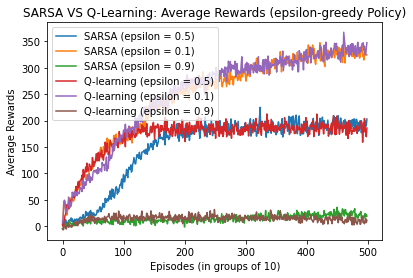

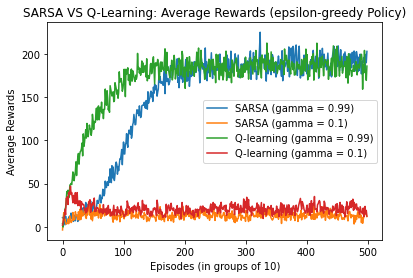

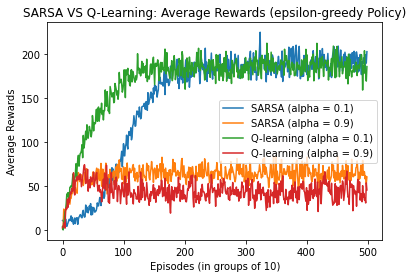

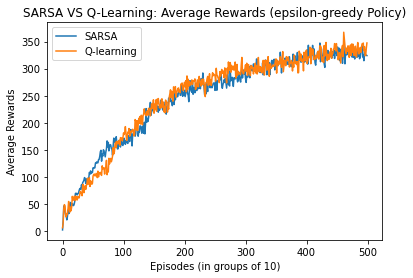

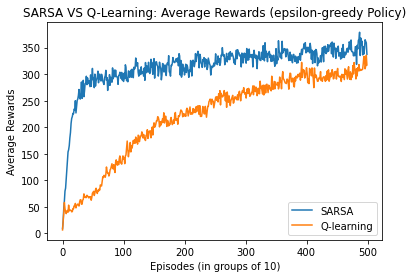

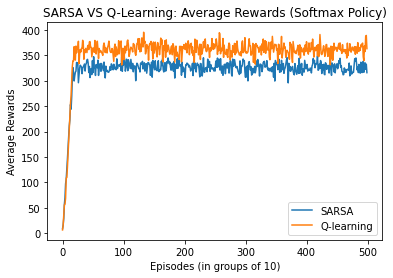

In [22]:
# Plotting

# Average rewards plots for different exploration rates.
plt.plot(np.mean(np.array(rewards_sarsa).reshape(-1, 10), axis=1), label = 'SARSA (epsilon = 0.5)')
plt.plot(np.mean(np.array(rewards_sarsa2).reshape(-1, 10), axis=1), label = 'SARSA (epsilon = 0.1)')
plt.plot(np.mean(np.array(rewards_sarsa3).reshape(-1, 10), axis=1), label = 'SARSA (epsilon = 0.9)')
plt.plot(np.mean(np.array(rewards_qlearning).reshape(-1, 10), axis=1), label = 'Q-learning (epsilon = 0.5)')
plt.plot(np.mean(np.array(rewards_qlearning2).reshape(-1, 10), axis=1), label = 'Q-learning (epsilon = 0.1)')
plt.plot(np.mean(np.array(rewards_qlearning3).reshape(-1, 10), axis=1), label = 'Q-learning (epsilon = 0.9)')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots for different discount factors.
plt.plot(np.mean(np.array(rewards_sarsa).reshape(-1, 10), axis=1), label = 'SARSA (gamma = 0.99)')
plt.plot(np.mean(np.array(rewards_sarsa4).reshape(-1, 10), axis=1), label = 'SARSA (gamma = 0.1)')
plt.plot(np.mean(np.array(rewards_qlearning).reshape(-1, 10), axis=1), label = 'Q-learning (gamma = 0.99)')
plt.plot(np.mean(np.array(rewards_qlearning4).reshape(-1, 10), axis=1), label = 'Q-learning (gamma = 0.1)')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots for different learning rates.
plt.plot(np.mean(np.array(rewards_sarsa).reshape(-1, 10), axis=1), label = 'SARSA (alpha = 0.1)')
plt.plot(np.mean(np.array(rewards_sarsa5).reshape(-1, 10), axis=1), label = 'SARSA (alpha = 0.9)')
plt.plot(np.mean(np.array(rewards_qlearning).reshape(-1, 10), axis=1), label = 'Q-learning (alpha = 0.1)')
plt.plot(np.mean(np.array(rewards_qlearning5).reshape(-1, 10), axis=1), label = 'Q-learning (alpha = 0.9)')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots (epsilon-greedy).
plt.plot(np.mean(np.array(rewards_sarsa2).reshape(-1, 10), axis=1), label = 'SARSA')
plt.plot(np.mean(np.array(rewards_qlearning2).reshape(-1, 10), axis=1), label = 'Q-learning')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots (epsilon-greedy) when implementing an eligibility trace.
plt.plot(np.mean(np.array(rewards_sarsa6).reshape(-1, 10), axis=1), label = 'SARSA')
plt.plot(np.mean(np.array(rewards_qlearning6).reshape(-1, 10), axis=1), label = 'Q-learning')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (epsilon-greedy Policy)')
plt.legend()
plt.show()

# Average rewards plots (Softmax).
plt.plot(np.mean(np.array(rewards_sarsa7).reshape(-1, 10), axis=1), label = 'SARSA')
plt.plot(np.mean(np.array(rewards_qlearning7).reshape(-1, 10), axis=1), label = 'Q-learning')
plt.ylabel('Average Rewards')
plt.xlabel('Episodes (in groups of 10)')
plt.title('SARSA VS Q-Learning: Average Rewards (Softmax Policy)')
plt.legend()
plt.show()